# Solar Power Forecasting

##### Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox

In [8]:
plt.style.use('seaborn-v0_8')
plt.rcParams["figure.figsize"] = (12,5)

##### Load Datasets

In [9]:
gen_file = "Plant_1_Generation_Data.csv"
weather_file = "Plant_1_Weather_Sensor_Data.csv"

plant_gen = pd.read_csv(gen_file)
plant_weather = pd.read_csv(weather_file)

print("Generation Data Shape:", plant_gen.shape)
print("Weather Data Shape:", plant_weather.shape)

Generation Data Shape: (68778, 7)
Weather Data Shape: (3182, 6)


##### Convert DATE_TIME to datetime

In [10]:
plant_gen['datetime'] = pd.to_datetime(plant_gen['DATE_TIME'], dayfirst=True)
plant_weather['datetime'] = pd.to_datetime(plant_weather['DATE_TIME'], dayfirst=True)

C:\Users\USER-PC\AppData\Local\Temp\ipykernel_3028\146805977.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  plant_weather['datetime'] = pd.to_datetime(plant_weather['DATE_TIME'], dayfirst=True)


##### Aggregate Generation Data

In [11]:
plant_gen_total = plant_gen.groupby('datetime')['AC_POWER'].sum().reset_index()

##### Aggregate Weather Data

In [12]:
plant_weather_avg = plant_weather.groupby('datetime')[
    ['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']
].mean().reset_index()


##### Merge Generation + Weather

In [13]:
data = pd.merge(plant_gen_total, plant_weather_avg, on='datetime', how='inner')

In [14]:
data.set_index('datetime', inplace=True)

print("\nMerged Data Sample:")
print(data.head())


Merged Data Sample:
                     AC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
datetime                                                                 
2020-05-15 00:00:00       0.0            25.184316           22.857507   
2020-05-15 00:15:00       0.0            25.084589           22.761668   
2020-05-15 00:30:00       0.0            24.935753           22.592306   
2020-05-15 00:45:00       0.0            24.846130           22.360852   
2020-05-15 01:00:00       0.0            24.621525           22.165423   

                     IRRADIATION  
datetime                          
2020-05-15 00:00:00          0.0  
2020-05-15 00:15:00          0.0  
2020-05-15 00:30:00          0.0  
2020-05-15 00:45:00          0.0  
2020-05-15 01:00:00          0.0  


In [15]:
data.head()

,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
datetime,,,,
2020-05-15 00:00:00,0.0,25.184316,22.857507,0.0
2020-05-15 00:15:00,0.0,25.084589,22.761668,0.0
2020-05-15 00:30:00,0.0,24.935753,22.592306,0.0
2020-05-15 00:45:00,0.0,24.846130,22.360852,0.0
2020-05-15 01:00:00,0.0,24.621525,22.165423,0.0


In [35]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3157 entries, 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AC_POWER             3157 non-null   float64
 1   AMBIENT_TEMPERATURE  3157 non-null   float64
 2   MODULE_TEMPERATURE   3157 non-null   float64
 3   IRRADIATION          3157 non-null   float64
dtypes: float64(4)
memory usage: 123.3 KB


In [36]:
data.describe()

,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3157.000000,3157.000000,3157.000000,3157.000000
mean,6704.830534,25.560257,31.175453,0.230103
std,8604.217954,3.351059,12.272685,0.301348
min,0.000000,20.398505,18.140415,0.000000
25%,0.000000,22.739895,21.130249,0.000000
50%,814.880357,24.680324,24.801971,0.027748
75%,13752.112500,27.941221,41.449481,0.451576
max,29150.212499,35.252486,65.545714,1.221652


In [40]:

data['Year'] = data.index.year

yearly_trend = data.groupby('Year')['AC_POWER'].mean()

print(yearly_trend)


Year
2020    6704.830534
Name: AC_POWER, dtype: float64


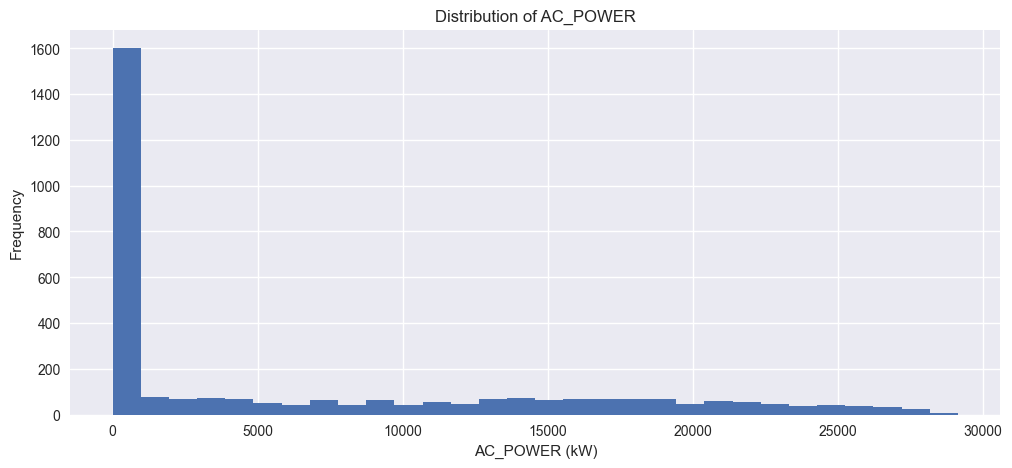

In [42]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(data["AC_POWER"], bins=30)
plt.title("Distribution of AC_POWER")
plt.xlabel("AC_POWER (kW)")
plt.ylabel("Frequency")
plt.show()

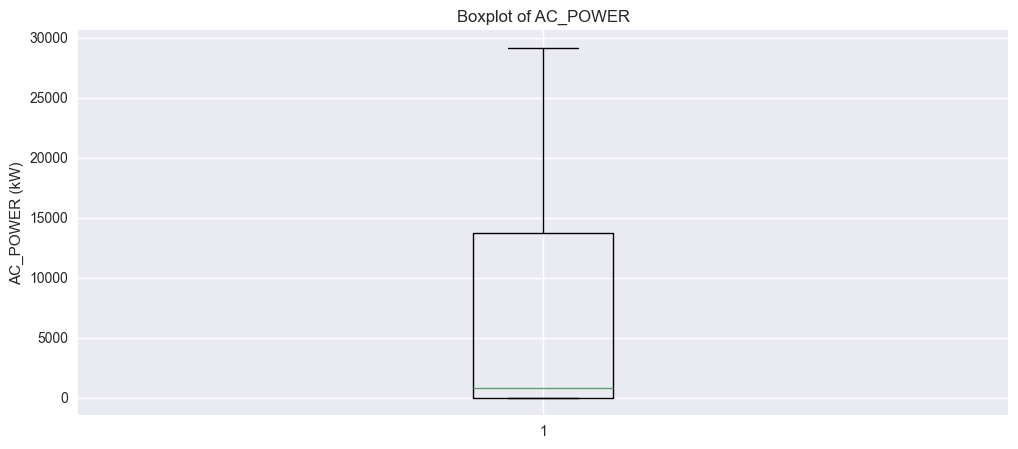

In [43]:
plt.figure()
plt.boxplot(data["AC_POWER"])
plt.title("Boxplot of AC_POWER")
plt.ylabel("AC_POWER (kW)")
plt.show()

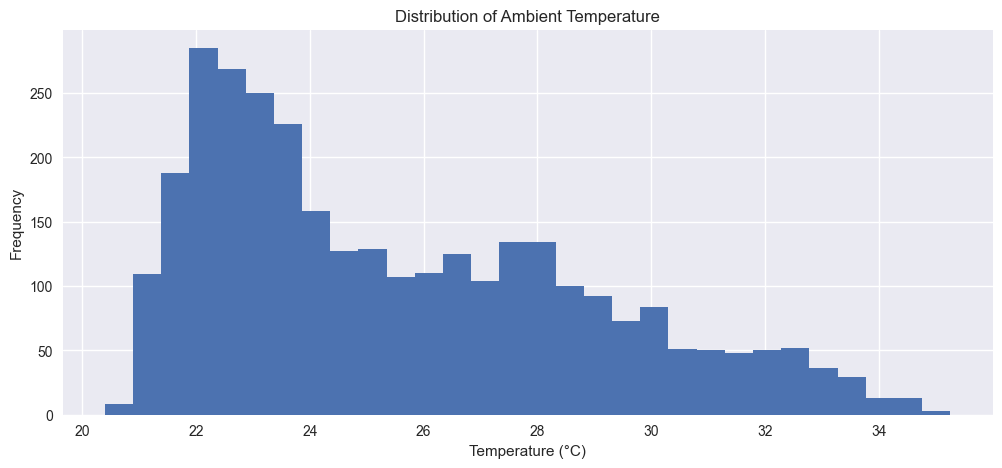

In [45]:
plt.figure()
plt.hist(data["AMBIENT_TEMPERATURE"], bins=30)
plt.title("Distribution of Ambient Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

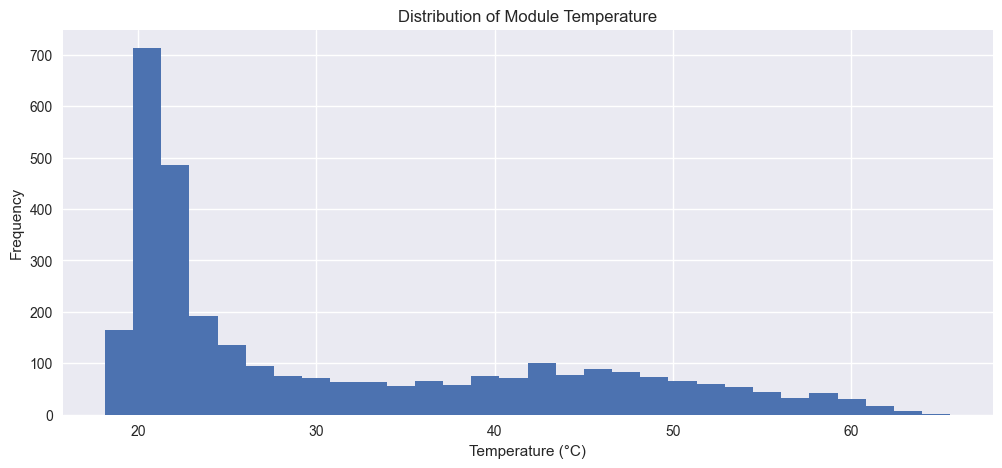

In [48]:
plt.figure()
plt.hist(data["MODULE_TEMPERATURE"], bins=30)
plt.title("Distribution of Module Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

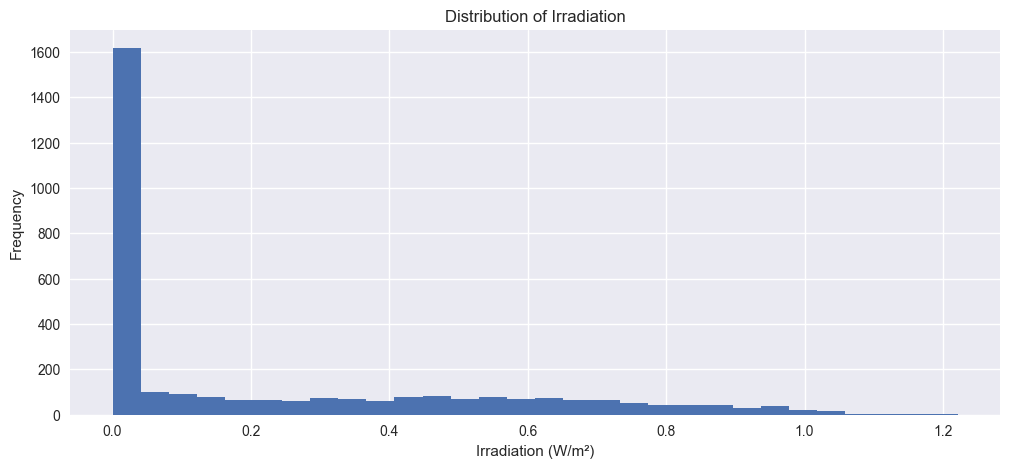

In [49]:
plt.figure()
plt.hist(data["IRRADIATION"], bins=30)
plt.title("Distribution of Irradiation")
plt.xlabel("Irradiation (W/m²)")
plt.ylabel("Frequency")
plt.show()

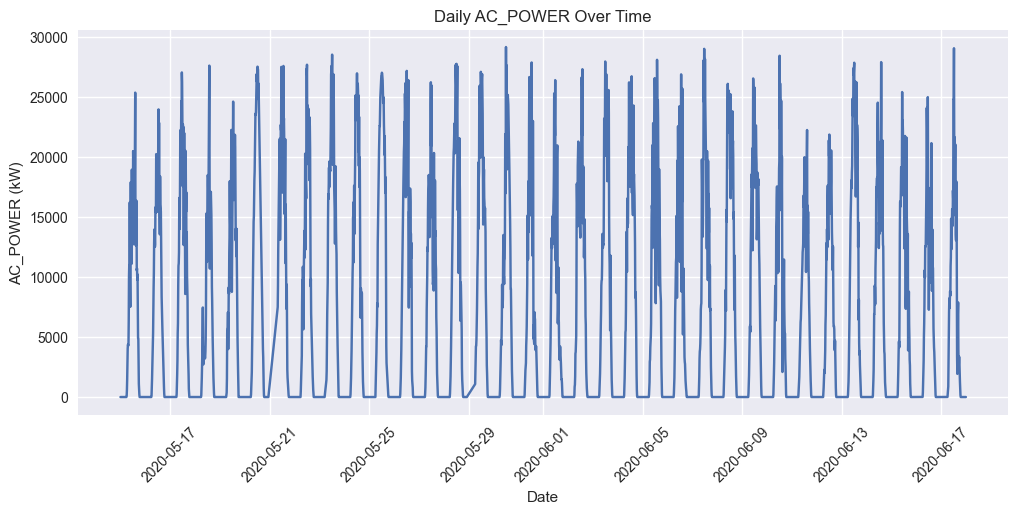

In [51]:
plt.figure()
plt.plot(data.index, data["AC_POWER"])
plt.title("Daily AC_POWER Over Time")
plt.xlabel("Date")
plt.ylabel("AC_POWER (kW)")
plt.xticks(rotation=45)
plt.show()

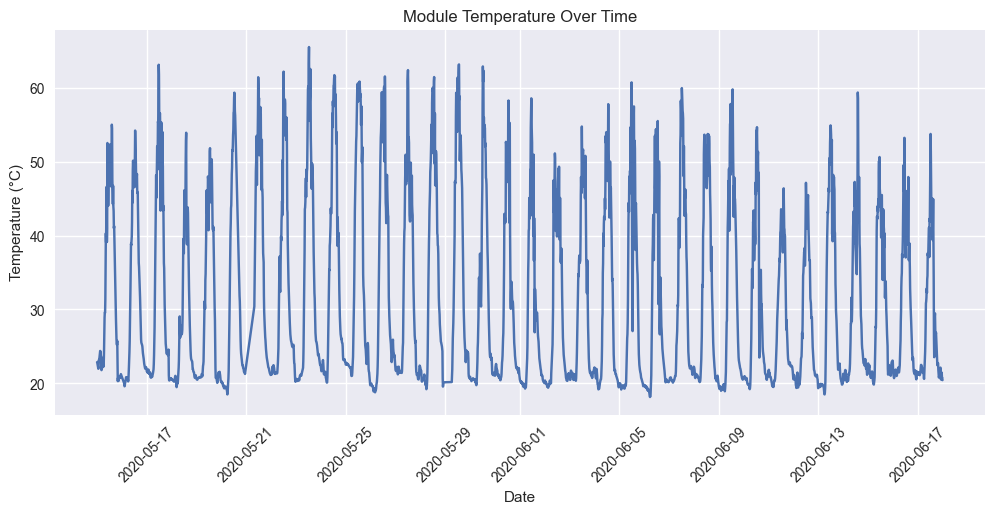

In [52]:
plt.figure()
plt.plot(data.index, data["MODULE_TEMPERATURE"])
plt.title("Module Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.show()

##### Resample to Daily Data

In [16]:
daily_data = data.resample('D').agg({
    'AC_POWER':'sum',
    'AMBIENT_TEMPERATURE':'mean',
    'MODULE_TEMPERATURE':'mean',
    'IRRADIATION':'mean'
})

print("\nDaily Data Sample:")
print(daily_data.head())


Daily Data Sample:
                 AC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
datetime                                                             
2020-05-15  550830.959402            27.430823           32.582964   
2020-05-16  568359.821428            26.780538           31.858851   
2020-05-17  660975.389285            26.686727           32.740435   
2020-05-18  470969.708929            23.850938           27.814344   
2020-05-19  532250.491070            25.338021           29.725163   

            IRRADIATION  
datetime                 
2020-05-15     0.204699  
2020-05-16     0.211951  
2020-05-17     0.238869  
2020-05-18     0.159026  
2020-05-19     0.194031  


##### Exploratory Analysis

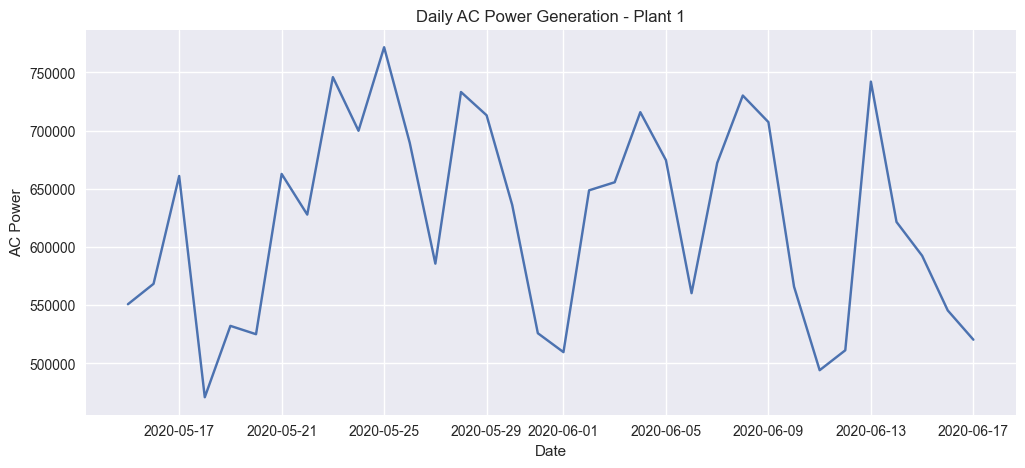

In [17]:
plt.plot(daily_data['AC_POWER'])
plt.title("Daily AC Power Generation - Plant 1")
plt.xlabel("Date")
plt.ylabel("AC Power")
plt.show()

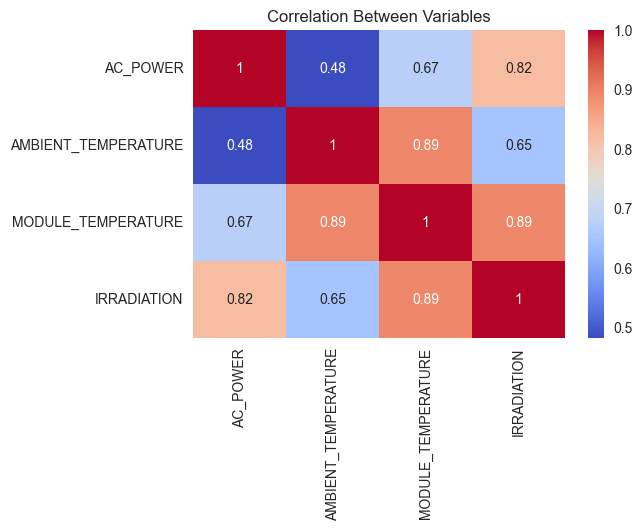

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(daily_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Variables")
plt.show()

##### Check Stationarity

In [19]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_test(daily_data['AC_POWER'])

ADF Statistic: -3.489501124070394
p-value: 0.008260857015114576


In [20]:
daily_data['AC_POWER_diff'] = daily_data['AC_POWER'].diff()

adf_test(daily_data['AC_POWER_diff'].dropna())

ADF Statistic: -4.730988870881036
p-value: 7.356785441225453e-05


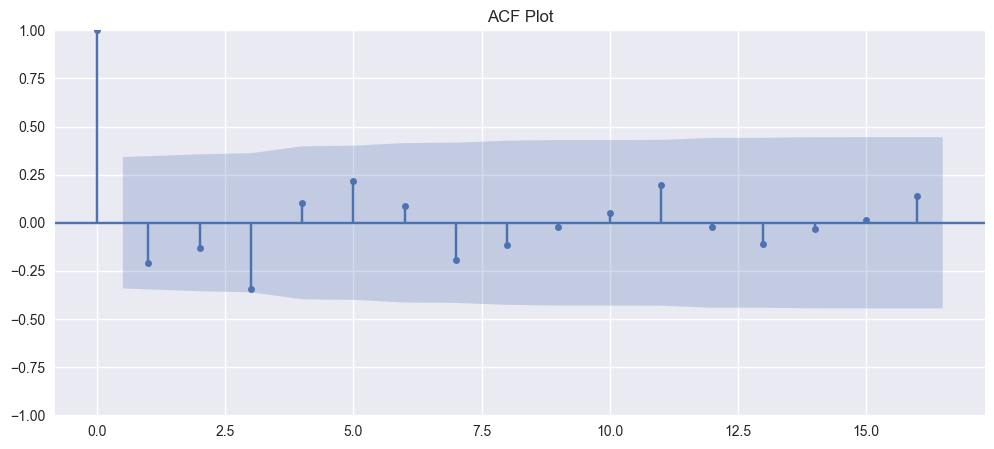

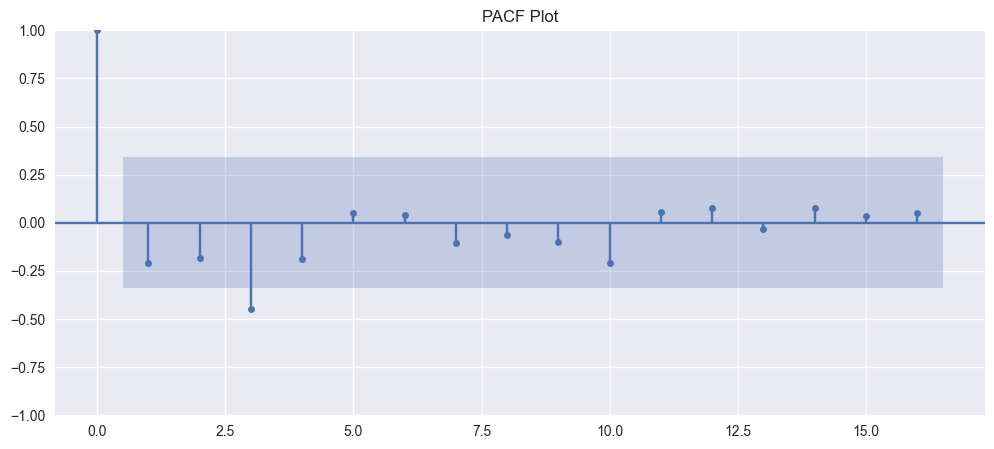

In [21]:
plot_acf(daily_data['AC_POWER_diff'].dropna())
plt.title("ACF Plot")
plt.show()

plot_pacf(daily_data['AC_POWER_diff'].dropna())
plt.title("PACF Plot")
plt.show()

##### Seasonal Decomposition

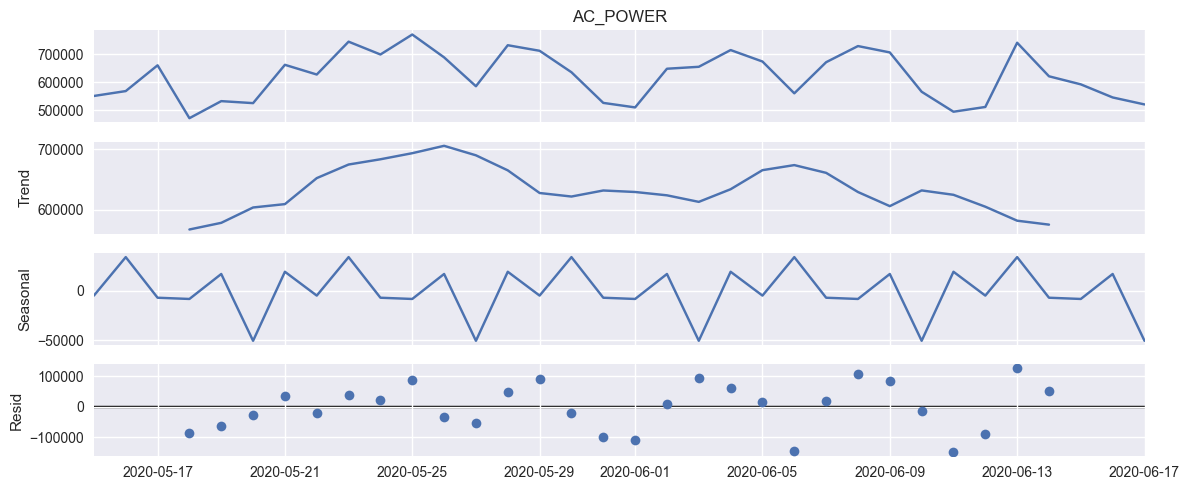

In [22]:
decompose = seasonal_decompose(daily_data['AC_POWER'], model='additive', period=7)
decompose.plot()
plt.show()

##### Polynomial

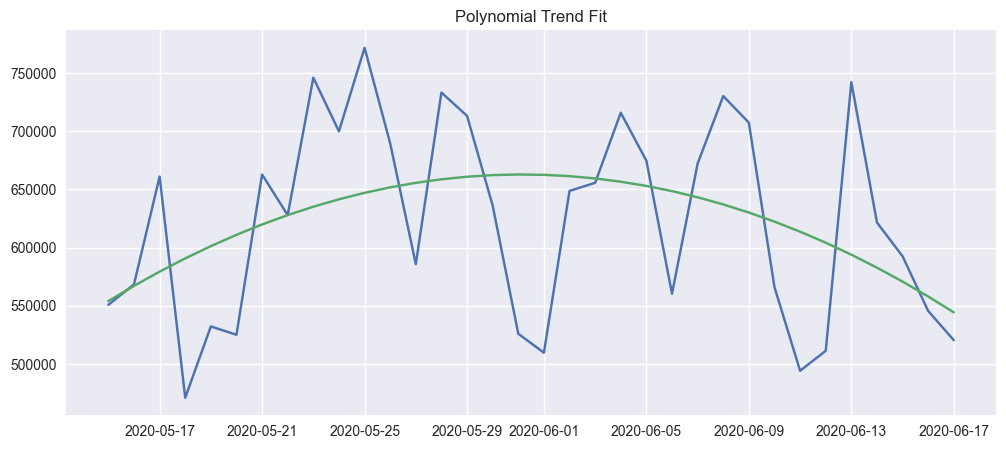

Polynomial RMSE: 77005.2764660983


In [23]:
t = np.arange(len(daily_data))
coeff = np.polyfit(t, daily_data['AC_POWER'], 2)
trend = np.polyval(coeff, t)

plt.plot(daily_data.index, daily_data['AC_POWER'])
plt.plot(daily_data.index, trend)
plt.title("Polynomial Trend Fit")
plt.show()

poly_rmse = np.sqrt(mean_squared_error(daily_data['AC_POWER'], trend))
print("Polynomial RMSE:", poly_rmse)

##### Train-Test Split

In [24]:
train_size = int(len(daily_data)*0.8)

train = daily_data.iloc[:train_size]
test = daily_data.iloc[train_size:]

y_train = train['AC_POWER']
y_test = test['AC_POWER']

X_train = train[['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']]
X_test = test[['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']]

In [54]:
X_test.shape,y_test.shape

((7, 3), (7,))

In [55]:
X_test[:10]

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
datetime,,,
2020-06-11,24.403410,27.880257,0.161809
2020-06-12,24.072379,27.585834,0.169808
2020-06-13,24.566729,30.481026,0.264472
2020-06-14,24.412891,29.421707,0.220086
2020-06-15,24.827414,29.927817,0.205925
2020-06-16,24.928929,29.555567,0.187283
2020-06-17,24.273244,28.522974,0.180157


##### Fit SARIMAX Model

In [25]:
model_arima = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

results_arima = model_arima.fit()

forecast_arima = results_arima.get_forecast(steps=len(test))
pred_arima = forecast_arima.predicted_mean

rmse_arima = np.sqrt(mean_squared_error(y_test, pred_arima))

print("ARIMA RMSE:", rmse_arima)
print("ARIMA AIC:", results_arima.aic)

c:\Users\USER-PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\USER-PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\USER-PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA RMSE: 148789.71894763794
ARIMA AIC: 505.6493615493753


In [26]:
model_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

results_sarimax = model_sarimax.fit()

forecast_sarimax = results_sarimax.get_forecast(
    steps=len(test),
    exog=X_test
)

pred_sarimax = forecast_sarimax.predicted_mean

rmse_sarimax = np.sqrt(mean_squared_error(y_test, pred_sarimax))

print("SARIMAX RMSE:", rmse_sarimax)
print("SARIMAX AIC:", results_sarimax.aic)

SARIMAX RMSE: 20990.9439222099
SARIMAX AIC: 482.6211579285485


c:\Users\USER-PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [27]:
rmse_arima = np.sqrt(mean_squared_error(y_test, pred_arima))
rmse_sarimax = np.sqrt(mean_squared_error(y_test, pred_sarimax))

mae_arima = mean_absolute_error(y_test, pred_arima)
mae_sarimax = mean_absolute_error(y_test, pred_sarimax)

print("ARIMA RMSE:", rmse_arima)
print("SARIMAX RMSE:", rmse_sarimax)
print("ARIMA MAE:", mae_arima)
print("SARIMAX MAE:", mae_sarimax)

ARIMA RMSE: 148789.71894763794
SARIMAX RMSE: 20990.9439222099
ARIMA MAE: 141700.6031322176
SARIMAX MAE: 17028.595806250923


In [28]:
forecast_mean = forecast_sarimax.predicted_mean
forecast_ci = forecast_sarimax.conf_int()

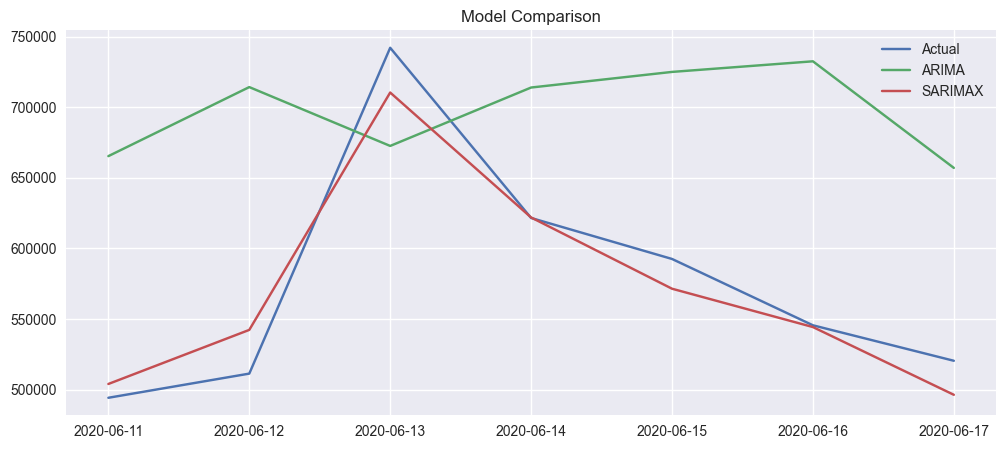

In [29]:
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, pred_arima, label="ARIMA")
plt.plot(y_test.index, pred_sarimax, label="SARIMAX")
plt.legend()
plt.title("Model Comparison")
plt.show()

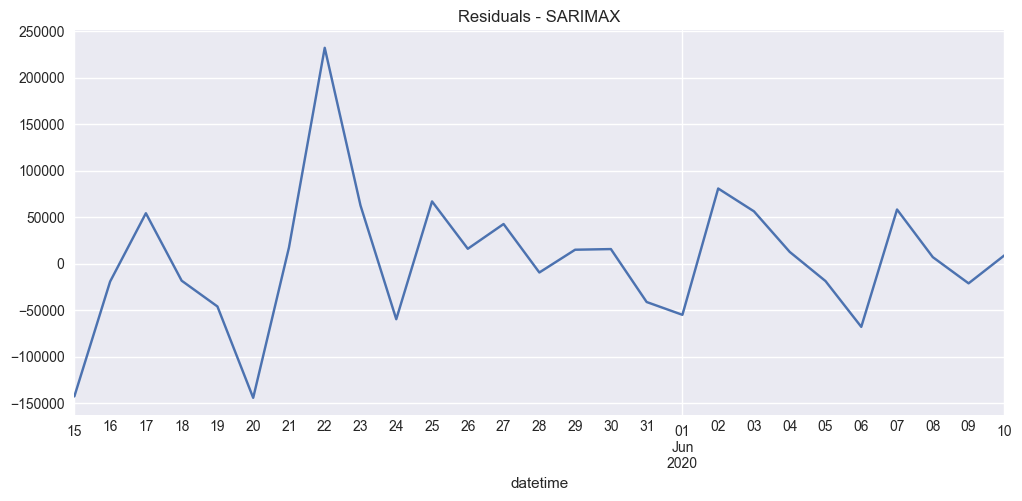

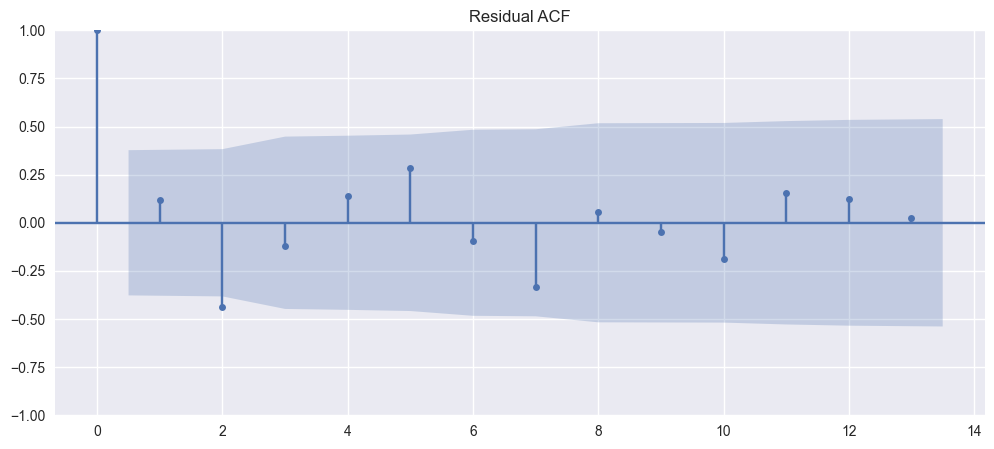

In [30]:
results_sarimax.resid.plot()
plt.title("Residuals - SARIMAX")
plt.show()

plot_acf(results_sarimax.resid)
plt.title("Residual ACF")
plt.show()

In [31]:
ljung_box = acorr_ljungbox(results_sarimax.resid, lags=[10], return_df=True)
print(ljung_box)

      lb_stat  lb_pvalue
10  16.948796   0.075505


##### Plot Forecast vs Actual

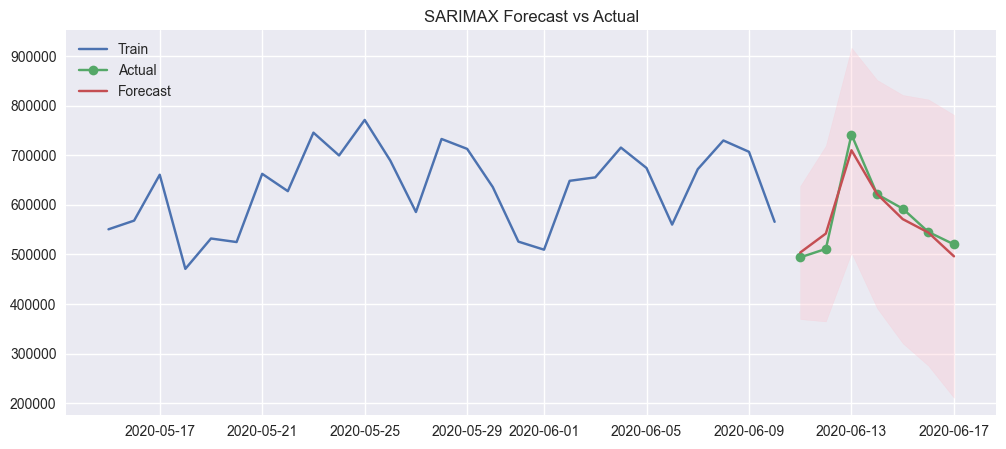

In [32]:
plt.plot(y_train, label='Train')
plt.plot(y_test, label='Actual', marker='o')
plt.plot(forecast_mean, label='Forecast', marker='x')
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color='pink', alpha=0.3
)
plt.title("SARIMAX Forecast vs Actual")
plt.legend()
plt.show()


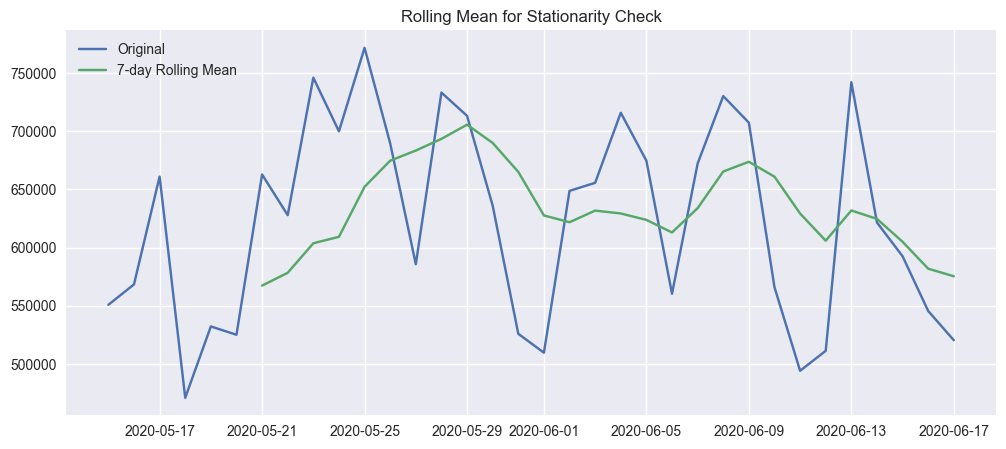

In [33]:
rolling_mean = daily_data['AC_POWER'].rolling(window=7).mean()

plt.plot(daily_data['AC_POWER'], label='Original')
plt.plot(rolling_mean, label='7-day Rolling Mean')
plt.legend()
plt.title("Rolling Mean for Stationarity Check")
plt.show()

##### Forecast Next 7 Days

In [34]:
future_exog = X_test.iloc[-7:]

future_forecast = results_sarimax.get_forecast(
    steps=7,
    exog=future_exog
)

future_values = future_forecast.predicted_mean

print("Next 7 Days Forecast:")
print(future_values)

Next 7 Days Forecast:
2020-06-11    503949.823492
2020-06-12    542247.571178
2020-06-13    710343.669517
2020-06-14    621872.374869
2020-06-15    571411.059743
2020-06-16    544256.725626
2020-06-17    496291.025277
Freq: D, Name: predicted_mean, dtype: float64
